In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


# Load one asset as example
aapl = pd.read_csv("../data/raw/AAPL.csv", index_col=0, parse_dates=True)

# Use adjusted close
prices = pd.to_numeric(aapl["Close"], errors="coerce")
prices = prices.replace([np.inf, -np.inf], np.nan).dropna()

prices.head()


C:\Users\yogst\AppData\Local\Temp\ipykernel_21216\600096222.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  aapl = pd.read_csv("../data/raw/AAPL.csv", index_col=0, parse_dates=True)


Price
2020-01-02    72.468269
2020-01-03    71.763710
2020-01-06    72.335541
2020-01-07    71.995354
2020-01-08    73.153496
Name: Close, dtype: float64

In [16]:
import numpy as np

log_returns = np.log(prices).diff().dropna()
log_returns.head()


Price
2020-01-03   -0.009770
2020-01-06    0.007937
2020-01-07   -0.004714
2020-01-08    0.015958
2020-01-09    0.021018
Name: Close, dtype: float64

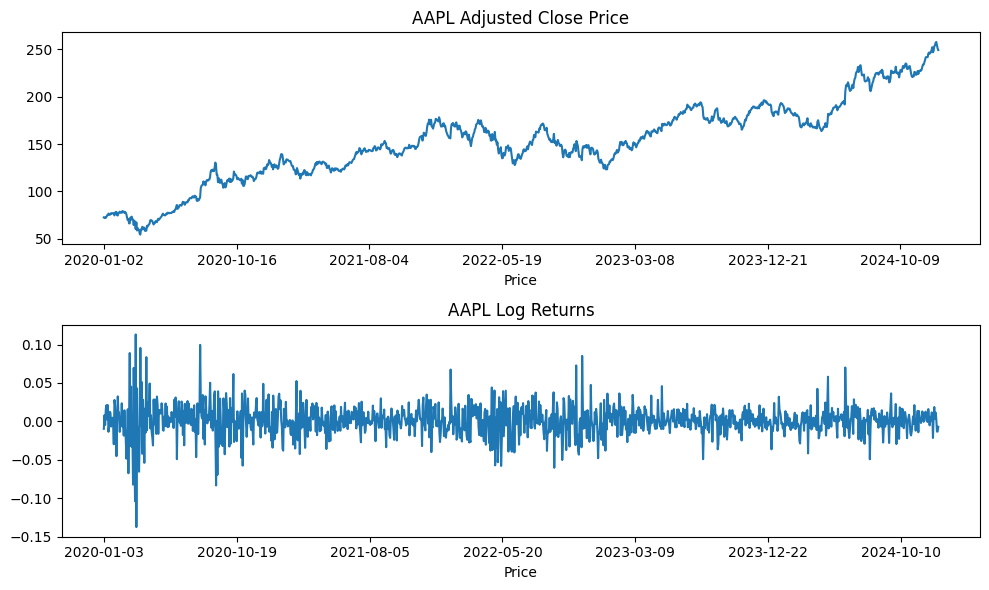

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

prices.plot(ax=axes[0], title="AAPL Adjusted Close Price")
log_returns.plot(ax=axes[1], title="AAPL Log Returns")

plt.tight_layout()
plt.show()


In [18]:
adf_price = adfuller(prices)

print("ADF statistic (prices):", adf_price[0])
print("p-value (prices):", adf_price[1])


ADF statistic (prices): -0.708405614492755
p-value (prices): 0.8445602638236909


In [ ]:
adf_returns = adfuller(log_returns)

print("ADF statistic (returns):", adf_returns[0])
print("p-value (returns):", adf_returns[1])


### Stationarity Findings

- Equity prices exhibit non-stationary behaviour.
- Log returns are much closer to stationarity.
- This motivates working with returns or stationary transformations
  when designing statistical trading strategies.


### Note to me
- A log return is the natural logarithm of the ratio of the an asset's final price to it's intial price, showing it's continously compound return (showing its return every second ie continous data not discrete).
- Stationarity tests (ADF) checks if a time series (a sequence of data points in ordered over time) behaves consistently over time.
- 2nd bullet point in findings means that the log returns to fluctuate around a stable average, so we can apply statistical models to these (which require stationarity)